In [71]:
import cv2
from pathlib import Path
from huggingface_hub import hf_hub_download
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator, Colors
from matplotlib import pyplot as plt

# --- Configuration ---
# Choisissez le modèle à utiliser : 0: nano, 1: small, 2: medium
# Le modèle nano est le plus rapide, le medium est le plus précis.
MODEL_INDEX = 0 
MODEL_FILES = [
    "yolo11n_doc_layout.pt",
    "yolo11s_doc_layout.pt",
    "yolo11m_doc_layout.pt",
]
SELECTED_MODEL_FILE = MODEL_FILES[MODEL_INDEX]

# Chemin vers votre image de document
IMAGE_PATH = "../images/doc1.png" # <--- MODIFIEZ CECI

# --- Téléchargement du modèle ---
# Crée un dossier pour stocker les modèles téléchargés
DOWNLOAD_PATH = Path("./models")
DOWNLOAD_PATH.mkdir(exist_ok=True)

# Télécharge le modèle depuis le Hub Hugging Face s'il n'est pas déjà présent
try:
    model_path = hf_hub_download(
        repo_id="Armaggheddon/yolo11-document-layout",
        filename=SELECTED_MODEL_FILE,
        repo_type="model",
        local_dir=DOWNLOAD_PATH,
    )
    print(f"Modèle téléchargé à l'emplacement : {model_path}")
except Exception as e:
    print(f"Erreur lors du téléchargement du modèle : {e}")
    exit()


Couldn't access the Hub to check for update but local file already exists. Defaulting to existing file. (error: 401 Client Error. (Request ID: Root=1-690f5cac-468bf2b4417c99b302e7d7a5;107f57f0-6897-42e1-ad75-330c81d75836)

Repository Not Found for url: https://huggingface.co/Armaggheddon/yolo11-document-layout/resolve/main/yolo11n_doc_layout.pt.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
User Access Token "Token_Segmentation" is expired)


Modèle téléchargé à l'emplacement : models/yolo11n_doc_layout.pt


In [ ]:
# --- Inférence ---
# Charge le modèle YOLO
model = YOLO(model_path)

# Charge l'image
img = cv2.imread(IMAGE_PATH)
if img is None:
    print(f"Erreur : Impossible de charger l'image depuis {IMAGE_PATH}")
    exit()

# Effectue la prédiction
results = model.predict(img)

# --- Visualisation des résultats ---
# Crée un objet pour annoter l'image
annotator = Annotator(img, line_width=2, font_size=8)
colors = Colors() # Pour avoir des couleurs distinctes par classe



0: 1280x928 4 List-items, 1 Page-header, 4 Pictures, 14 Section-headers, 1 Table, 10 Texts, 138.4ms
Speed: 5.5ms preprocess, 138.4ms inference, 2.3ms postprocess per image at shape (1, 3, 1280, 928)


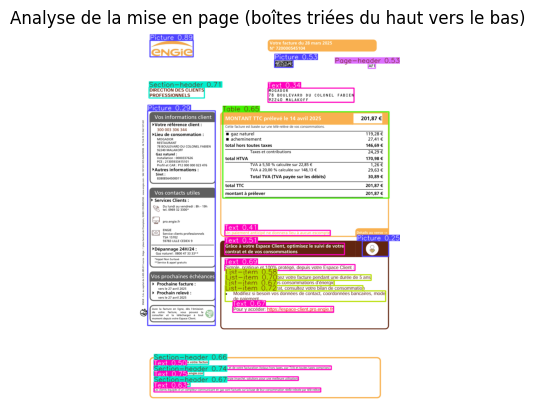

1. Picture (0.89) , y1 = 25.1
2. Picture (0.53) , y1 = 84.9
3. Page-header (0.53) , y1 = 95.1
4. Section-header (0.71) , y1 = 168.0
5. Text (0.34) , y1 = 170.8
6. Picture (0.29) , y1 = 239.3
7. Table (0.65) , y1 = 242.5
8. Text (0.41) , y1 = 602.7
9. Picture (0.25) , y1 = 634.3
10. Text (0.51) , y1 = 641.5
11. Text (0.69) , y1 = 706.7
12. List-item (0.58) , y1 = 737.1
13. List-item (0.70) , y1 = 753.7
14. List-item (0.67) , y1 = 770.2
15. List-item (0.72) , y1 = 786.2
16. Text (0.67) , y1 = 833.7
17. Section-header (0.66) , y1 = 997.0
18. Text (0.50) , y1 = 1014.6
19. Section-header (0.74) , y1 = 1031.1
20. Text (0.75) , y1 = 1047.2
21. Section-header (0.67) , y1 = 1064.6
22. Text (0.63) , y1 = 1081.3
✅ Table extraite et zoomée : table_crop_0.png
✅ Table extraite et zoomée : table_crop_1.png
✅ Table extraite et zoomée : table_crop_2.png
✅ Table extraite et zoomée : table_crop_3.png
✅ Table extraite et zoomée : table_crop_4.png
✅ Table extraite et zoomée : table_crop_5.png
✅ Table extra

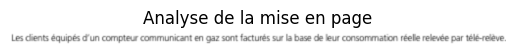

In [ ]:
img = cv2.imread(IMAGE_PATH)
annotator = Annotator(img, line_width=2, font_size=8)

boxes = results[0].boxes
filtered_boxes = []

# Convertit les boîtes au format (x1, y1, x2, y2)
all_boxes = [box.xyxy[0].tolist() for box in boxes]
all_classes = [int(box.cls) for box in boxes]
all_conf = [float(box.conf.item()) for box in boxes]

# Filtrage des boîtes contenues dans d'autres
for i, b1 in enumerate(all_boxes):
    x1_1, y1_1, x2_1, y2_1 = b1
    is_inside = False

    for j, b2 in enumerate(all_boxes):
        if i == j:
            continue
        x1_2, y1_2, x2_2, y2_2 = b2

        # Vérifie si la boîte b1 est totalement à l'intérieur de b2
        if (x1_1 >= x1_2 and y1_1 >= y1_2 and 
            x2_1 <= x2_2 and y2_1 <= y2_2):
            is_inside = True
            break

    # Si la boîte n'est pas à l'intérieur d'une autre, on la garde
    if not is_inside:
        filtered_boxes.append((b1, all_classes[i], all_conf[i]))

#  Trie les boîtes du haut vers le bas selon y1
filtered_boxes.sort(key=lambda b: b[0][1])  # tri par y1 croissant

# Crée une liste finale propre et exploitable
box_list = [
    {
        "coords": list(b),  # ← on force bien la liste ici
        "class": model.names[int(c)],
        "confidence": conf
    }
    for b, c, conf in filtered_boxes
]

# Dessine uniquement les boîtes conservées
for b, c, conf in filtered_boxes:
    label = f"{model.names[int(c)]} {conf:.2f}"
    annotator.box_label(b, label, color=colors(c, True))

# Récupère l'image annotée
annotated_img = annotator.result()

plt.title("Analyse de la mise en page (boîtes triées du haut vers le bas)")
plt.imshow(annotated_img, cmap='gray')
plt.axis("off")
plt.show()

# ✅ Affiche la liste triée sans erreur
for i, box_info in enumerate(box_list):
    x1, y1, x2, y2 = box_info["coords"]
    print(f"{i+1}. {box_info['class']} ({box_info['confidence']:.2f}) , y1 = {y1:.1f}")



crop_count = 0  # compteur pour nommer les fichiers

for b, c, conf in filtered_boxes:
    
    class_name = model.names[c]

    # Bounding box
    x1, y1, x2, y2 = map(int, b)
    
    label = f"{class_name} {conf:.2f}"
    annotator.box_label(b, label, color=colors(c, True))

    img = cv2.imread(IMAGE_PATH)
    # ---- CROP ET ZOOM ----
    crop = img[y1:y2, x1:x2]

    # Zoom (2x ici — change la valeur si besoin)
    zoom_factor = 2
    crop_zoom = cv2.resize(
        crop, 
        (crop.shape[1] * zoom_factor, crop.shape[0] * zoom_factor),
        interpolation=cv2.INTER_LINEAR
    )

    # Sauvegarder l'image zoomée
    crop_path = f"table_crop_{crop_count}.png"
    cv2.imwrite(crop_path, crop_zoom)
    print(f"✅ Table extraite et zoomée : {crop_path}")
    crop_count += 1

annotated_img = annotator.result()
plt.title("Analyse de la mise en page")
plt.imshow(crop_zoom, cmap='gray')  
plt.axis("off")

plt.show()


In [73]:
import cv2
import numpy as np

# Charger l'image
img = cv2.imread(IMAGE_PATH)
annotator = Annotator(img, line_width=2, font_size=8)
list_b = []
i=0
# Parcours les détections
for result in results:
    boxe = result.boxes
    for box in boxe:
        # Récupère les coordonnées de la boîte englobante
        b = box.xyxy[0]  # format (x1, y1, x2, y2)
        list_b.append(b)

        x1, y1, x2, y2 = map(int, b)
        
        # Coordonnées des 4 coins
        points = [
            (x1, y1),  # Coin haut-gauche
            (x2, y1),  # Coin haut-droit
            (x2, y2),  # Coin bas-droit
            (x1, y2),  # Coin bas-gauche
        ]
        # Couleurs BGR pour chaque point
        colors = [
            (255, 0, 0),   # Bleu
            (0, 255, 0),   # Vert
            (0, 0, 255),   # Rouge
            (255, 255, 0), # Jaune
        ]

        # Dessiner les points
        for point, color in zip(points, colors):
            cv2.circle(img, point, radius=5, color=color, thickness=-1)  # -1 pour remplir le cercle
        if i==1 : 
            break
        i+=1
        
print(square_in_square(list_b[1], list_b[0]))

# Afficher ou sauvegarder l'image
plt.title("Analyse de la mise en page")
plt.imshow(img, cmap='gray')  
plt.axis("off")

plt.show()


AttributeError: 'Tensor' object has no attribute 'xyxy'

In [74]:
def square_in_square(b1, b2) : 
    
    b1 = b1.xyxy[0]  # format (x1, y1, x2, y2)
    b1 = b1.tolist()
    
    b2 = b2.xyxy[0]  # format (x1, y1, x2, y2)
    b2 = b2.tolist()
    
    x1, y1, x2, y2 = map(int, b1)
    xa, ya, xb, yb = map(int, b2)
    if x1 <= xa <= x2 and x1 <= xb <= x2 and y1 <= ya <= y2 and y1 <= yb <= y2 :
        return "b2 in b1"
    elif not (x1 <= xa <= x2) and not (x1 <= xb <= x2) and not (y1 <= ya <= y2) and not (y1 <= yb <= y2) :
        return "b2 out b1"
    return "entre 2"


In [75]:
img = cv2.imread(IMAGE_PATH)

annotator = Annotator(img, line_width=2, font_size=8)

list_b = []
i=0
# Parcours les détections
for result in results:
    boxe = result.boxes
    for box in boxe:
        print(i)
        print(f'len(bb) : {len(list_b)}')

        
        if len(list_b) > 0 :
            for bb in list_b :
                skip = square_in_square(box, bb)
                print(f'skip : {skip}')
                if skip == "b2 in b1" :
                    list_b.remove(bb)
                elif skip == "b2 out b1" :
                    break
                else :
                    list_b.append(box)
                
        if len(list_b) == 0 :
            list_b.append(box)
        i+=1
            
print(f"Nombre de boîtes après filtrage : {len(list_b)}")
for box in list_b: 
    b = box.xyxy[0]
    # Récupère la classe (type d'élément) et la confiance
    c = box.cls
    conf = box.conf.item()
    label = f"{model.names[int(c)]} {conf:.2f}"
    
    # Dessine la boîte et le label sur l'image
    annotator.box_label(b, label, color=colors(c, True))


# Récupère l'image annotée
annotated_img = annotator.result()

plt.title("Analyse de la mise en page")
plt.imshow(annotated_img, cmap='gray')  
plt.axis("off")

plt.show()

0
len(bb) : 0
1
len(bb) : 1
skip : entre 2
skip : b2 in b1
2
len(bb) : 1
skip : entre 2
skip : b2 in b1
3
len(bb) : 1
skip : b2 out b1
4
len(bb) : 1
skip : entre 2
skip : b2 in b1
5
len(bb) : 1
skip : b2 out b1
6
len(bb) : 1
skip : b2 out b1
7
len(bb) : 1
skip : b2 out b1
8
len(bb) : 1
skip : b2 out b1
9
len(bb) : 1
skip : b2 out b1
10
len(bb) : 1
skip : b2 out b1
11
len(bb) : 1
skip : entre 2
skip : b2 in b1
12
len(bb) : 1
skip : b2 out b1
13
len(bb) : 1
skip : entre 2
skip : b2 in b1
14
len(bb) : 1
skip : b2 out b1
15
len(bb) : 1
skip : b2 out b1
16
len(bb) : 1
skip : b2 out b1
17
len(bb) : 1
skip : b2 out b1
18
len(bb) : 1
skip : entre 2
skip : b2 in b1
19
len(bb) : 1
skip : entre 2
skip : b2 in b1
20
len(bb) : 1
skip : b2 out b1
21
len(bb) : 1
skip : b2 out b1
22
len(bb) : 1
skip : b2 out b1
23
len(bb) : 1
skip : b2 out b1
24
len(bb) : 1
skip : entre 2
skip : b2 in b1
25
len(bb) : 1
skip : entre 2
skip : b2 in b1
26
len(bb) : 1
skip : b2 out b1
27
len(bb) : 1
skip : b2 out b1
28
le

TypeError: 'list' object is not callable

✅ Table extraite et zoomée : table_crop_0.png


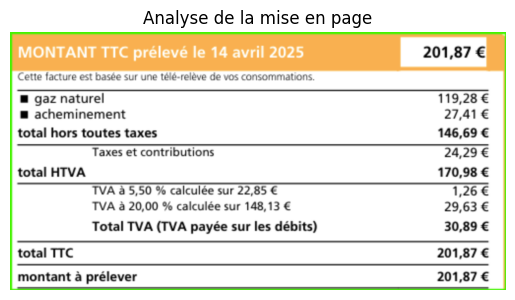

In [27]:
TARGET_CLASS = "Table"
crop_count = 0  # compteur pour nommer les fichiers

for result in results:
    boxes = result.boxes
    for box in boxes:
        c = int(box.cls.item())
        class_name = model.names[c]

        if class_name != TARGET_CLASS:
            continue

        # Bounding box
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        
        # Dessine la box sur l'image principale
        conf = box.conf.item()
        label = f"{class_name} {conf:.2f}"
        annotator.box_label(box.xyxy[0], label, color=colors(c, True))

        # ---- CROP ET ZOOM ----
        crop = img[y1:y2, x1:x2]

        # Zoom (2x ici — change la valeur si besoin)
        zoom_factor = 2
        crop_zoom = cv2.resize(
            crop, 
            (crop.shape[1] * zoom_factor, crop.shape[0] * zoom_factor),
            interpolation=cv2.INTER_LINEAR
        )

        # Sauvegarder l'image zoomée
        crop_path = f"table_crop_{crop_count}.png"
        cv2.imwrite(crop_path, crop_zoom)
        print(f"✅ Table extraite et zoomée : {crop_path}")
        crop_count += 1

annotated_img = annotator.result()
plt.title("Analyse de la mise en page")
plt.imshow(crop_zoom, cmap='gray')  
plt.axis("off")

plt.show()


In [30]:
# Sauvegarde l'image avec les détections
output_path = "resultat_analyse.png"
cv2.imwrite(output_path, annotated_img)
print(f"Image sauvegardée à l'emplacement : {output_path}")

Image sauvegardée à l'emplacement : resultat_analyse.png
